# SDS 210 Final project - Wildfire Mapping

load data, clean it map it in an interactive map


In [5]:
import os
print(os.getcwd())
print(os.listdir())

C:\Users\alina\SDS210\SDS_210_repository\sds210-main\sds210-wildfire-project\notebooks
['.ipynb_checkpoints', 'fire_project1.ipynb']


## 1. import all libraries and have a first look at data

In [26]:
#setup and imports
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import folium
from sklearn.cluster import DBSCAN ##for clustering
import numpy as np



#load data
#.. means move one folder up
df = pd.read_csv('../data/SUOMI_VIIRS_C2_SouthEast_Asia_7d.csv')

df = df[['latitude', 'longitude', 'bright_ti4', 'acq_date', 'confidence', 'bright_ti5', 'frp', 'daynight']]

df = df[df['confidence']!='low']

print(df['confidence'].value_counts())

print(df.info())

df.head(5)


confidence
nominal    16621
high         491
Name: count, dtype: int64
<class 'pandas.DataFrame'>
Index: 17112 entries, 0 to 19766
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   latitude    17112 non-null  float64
 1   longitude   17112 non-null  float64
 2   bright_ti4  17112 non-null  float64
 3   acq_date    17112 non-null  str    
 4   confidence  17112 non-null  str    
 5   bright_ti5  17112 non-null  float64
 6   frp         17112 non-null  float64
 7   daynight    17112 non-null  str    
dtypes: float64(5), str(3)
memory usage: 1.5 MB
None


,latitude,longitude,bright_ti4,acq_date,confidence,bright_ti5,frp,daynight
0,-10.12732,150.09003,325.34,2026-04-23,nominal,292.69,1.02,D
1,-10.10341,150.18076,349.79,2026-04-23,nominal,294.59,18.19,D
2,-10.10005,150.18001,350.95,2026-04-23,nominal,293.76,18.19,D
3,-10.06734,148.18779,327.24,2026-04-23,nominal,294.31,3.51,D
4,-10.01406,147.77792,332.74,2026-04-23,nominal,294.07,4.85,D


## 2. Load the world map

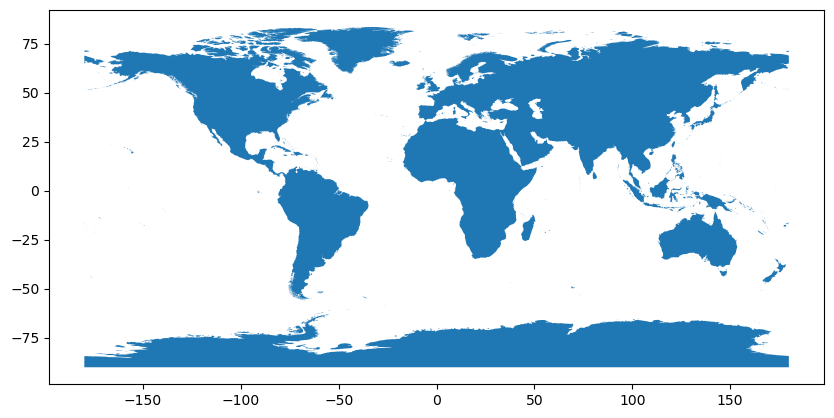

In [8]:
# Load the spatial data
land = gpd.read_file("../data/ne_10m_land.zip")

# The Standard Setup
fig, ax = plt.subplots(figsize=(10, 5))

# Plot the GeoDataFrame directly onto our specific Axes
land.plot(ax=ax)

plt.show()

## 3. Display fires
- crop the world map to the fire area and display each fire as red dot.
- each point represents a 375m satellite pixel

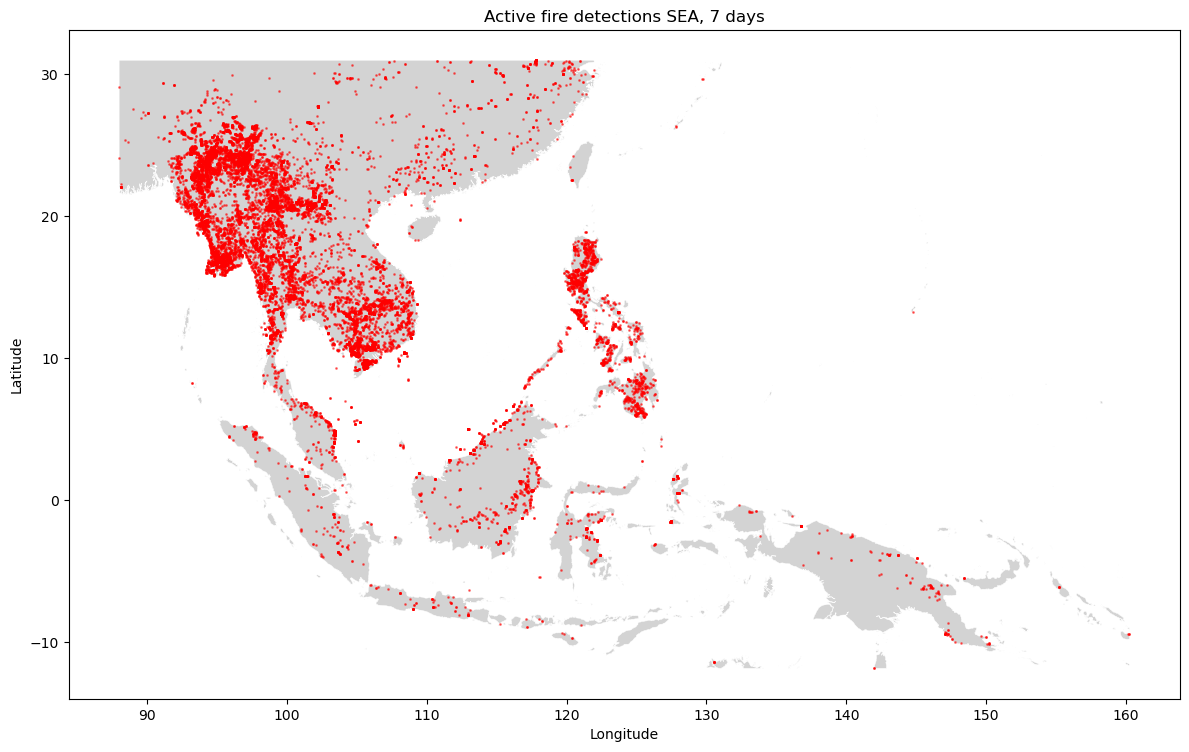

In [11]:
# Convert fire data to GeoDataFrame
fires_gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.longitude, df.latitude), crs="EPSG:4326")

# Clip land to Southeast Asia extent
sea_bounds = fires_gdf.total_bounds  # gets the bounding box of  fires
land_clipped = land.clip(sea_bounds)

# Plot
fig, ax = plt.subplots(figsize=(12, 8))
land_clipped.plot(ax=ax, color="lightgrey", edgecolor="white", linewidth=0.3)
fires_gdf.plot(ax=ax, color="red", markersize=1, alpha=0.5, zorder=2)

ax.set_title("Active fire detections SEA, 7 days")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

In [24]:
# Initialize map centered on Southeast Asia
m = folium.Map(
    location=[5, 115],  # roughly center of Southeast Asia
    zoom_start=3.47,
    tiles="CartoDB Positron" 
)

m